# Acoustic-Aware Fusion — 4-class dysarthria severity (UA-Speech)

## 1. Environment

In [1]:
import os
import shutil
import sys
import time
from pathlib import Path

SESSION_START = time.monotonic()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch

# Started from notebooks/ or the repo root: find the directory holding src/.
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.config as config
from src import feature_store
from src.aaflite.run import FINAL_TAG, PRIMARY_TAG, SUMMARY_PATH, prepare_features, run_experiments
from src.console import print_header, print_kv, print_note, print_status, silence_library_progress
from src.training.data import load_manifest
from src.training.models import SEVERITY_MODEL_NAME, build_model, parameter_counts
from src.training.reporting import (check_frozen_config_guard, collect_run_results, per_class_table,
                                    print_feature_audit, print_final_run_configuration,
                                    write_frozen_config)
from src.training.runner import TrainingConfig, build_folds, run_training
from src.training.session import calibrate_throughput, project_runtime, subset_blocks
from src.training.utils import (configure_local_runtime, gpu_temperature, memory_status,
                                on_battery, resolve_amp_dtype, resolve_device)
from src.vad_cache import verify_vad_span_cache

config.ensure_directories()
silence_library_progress()
# src.training.reporting selects the file-only Agg backend at import; display inline here.
%matplotlib inline
print_status(f"Project root: {PROJECT_ROOT}", ok=True)

  [ ✓ ] Project root: c:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification


In [2]:
device = resolve_device(None)
if device.type != "cuda":
    raise RuntimeError("CUDA is not available to this kernel — select the Python environment with "
                       "the CUDA build of torch (the 'torch-gpu' conda env).")
configure_local_runtime(device)          # cuDNN autotuning + a VRAM cap sized to free GPU memory

props = torch.cuda.get_device_properties(device)
gpu_free, gpu_total = torch.cuda.mem_get_info(device)
memory = memory_status()
print_header("Environment")
print_kv("Python / PyTorch / CUDA", f"{sys.version.split()[0]} / {torch.__version__} / {torch.version.cuda}")
print_kv("GPU", f"{props.name}, {gpu_total / 2**30:.1f} GiB ({gpu_free / 2**30:.1f} GiB free), "
                f"{gpu_temperature()} °C")
print_kv("CPU", f"{psutil.cpu_count(logical=False)} cores / {psutil.cpu_count()} threads")
print_kv("RAM / commit free", f"{memory['ram_available']:.1f} of {memory['ram_total']:.1f} GiB / "
                              f"{memory['commit_available']:.1f} of {memory['commit_limit']:.1f} GiB")
print_kv("Disk free", f"{shutil.disk_usage(PROJECT_ROOT).free / 2**30:.0f} GiB")
print_kv("Power", "battery — training will wait for the charger" if on_battery() else "plugged in")
print_kv("Precision", str(resolve_amp_dtype(device)).replace("torch.", "") + " autocast")
print_kv("Thermal guard", f"pause at {config.GPU_TEMP_PAUSE_C} °C, resume at {config.GPU_TEMP_RESUME_C} °C")
# A fold commits ~10 GiB (on Windows the GPU memory PyTorch reserves counts too)
# plus ~2 GiB for its data-loading worker.
if memory["ram_available"] < 4 or memory["commit_available"] < 14:
    print_note("Little memory is free — close browsers and other heavy applications before training.")


══════════════════════════════════════════════════════════════════════════════
  ENVIRONMENT
══════════════════════════════════════════════════════════════════════════════
  Python / PyTorch / CUDA ................. 3.10.20 / 2.5.1+cu121 / 12.1
  GPU ..................................... NVIDIA GeForce RTX 4060 Laptop GPU, 8.0 GiB (6.9 GiB free), 53 °C
  CPU ..................................... 14 cores / 20 threads
  RAM / commit free ....................... 3.2 of 15.6 GiB / 20.3 of 37.6 GiB
  Disk free ............................... 141 GiB
  Power ................................... plugged in
  Precision ............................... float16 autocast
  Thermal guard ........................... pause at 83 °C, resume at 72 °C
  • Little memory is free — close browsers and other heavy applications before training.


## 2. Data
UA-Speech, microphone M6: 15 dysarthric speakers (the evaluation set) and 13 healthy controls (used only as the per-word reference of section 4 — never trained on, never tested).

In [3]:
from src.extraction import extract_all_archives
from src.scanning import scan_audio_files, verify_speakers

EXPECTED_M6 = len(config.ALL_SPEAKERS) * config.WORDS_PER_SPEAKER          # 28 x 765
present = sum(1 for _ in config.AUDIO_DIR.rglob(f"*_{config.TARGET_MIC}.wav")) if config.AUDIO_DIR.exists() else 0
if present >= EXPECTED_M6:
    print_status(f"{present:,} {config.TARGET_MIC} files present in {config.AUDIO_DIR}.", ok=True)
else:
    missing = [str(config.ARCHIVE_DIR / name) for name in config.ARCHIVE_FILES
               if not (config.ARCHIVE_DIR / name).exists()]
    if missing:
        raise FileNotFoundError(f"Only {present:,}/{EXPECTED_M6:,} M6 files extracted and the archives "
                                f"are missing: {missing}")
    extract_all_archives()
    verify_speakers(scan_audio_files())

  [ ✓ ] 21,420 M6 files present in C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\extracted.


In [4]:
df_full = load_manifest()          # outputs/m6_manifest.csv (regenerated from the audio if absent)
missing_files = int((~df_full["Filepath"].map(os.path.exists)).sum())
if missing_files:
    raise FileNotFoundError(f"{missing_files:,} manifest files are missing — delete "
                            f"{config.MANIFEST_PATH} to regenerate it.")
print_header("Manifest")
print_kv("Utterances (M6) / speakers", f"{len(df_full):,} / {df_full['Speaker_ID'].nunique()}")
composition = df_full.groupby(["Severity", "Block"]).size().unstack(fill_value=0)
composition["total"] = composition.sum(axis=1)
display(composition)


══════════════════════════════════════════════════════════════════════════════
  DATASET SCAN
══════════════════════════════════════════════════════════════════════════════
  Scanning folder ......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\extracted
  Valid audio files ....................... 143565
  Skipped files ........................... 0
  Unique speakers ......................... 28

─── Microphone Filter (M6 only) ──────────────────────────────────────────────
  Total M6 samples ........................ 21420
    Dysarthric Patient .................... 11475
    Healthy Control ....................... 9945
  Missing dysarthric speakers on M6 ....... None
  Missing control speakers on M6 .......... None

─── WAV Header Validation ────────────────────────────────────────────────────
  Files checked ........................... 21420
  Corrupted (dropped) ..................... 0
  [ ✓ ] All files have 

Block,B1,B2,B3,total
Severity,,,,
High,1275,1275,1275,3825
Low,765,765,765,2295
Mid,765,765,765,2295
N/A (Control),3315,3315,3315,9945
Very Low,1020,1020,1020,3060


## 3. Feature store
VAD spans and the frame-wise segmental (43 × 401) and suprasegmental (3 × 401) features of every
utterance, for **all 28 speakers**, in resumable per-(speaker, block) chunks. Sampled entries are
re-computed live and must match bit for bit.

In [5]:
feature_store.build_feature_store(df_full, n_workers=config.FEATURE_STORE_WORKERS)
coverage = feature_store.feature_store_coverage(df_full)
if not coverage["complete"]:
    raise RuntimeError(f"Feature store incomplete (missing {coverage['chunks_missing']}) — re-run this cell.")
verify_vad_span_cache(df_full, n=300)
feature_store.verify_feature_store(df_full, n=24)


─── Feature store — 21,420 utterances in 84 chunk(s) ─────────────────────────
  Store directory ......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\feature_cache\store
  Chunks already complete ................. 0 / 84
  Chunks to build ......................... 84 (21,420 utterances)
  [ ✓ ] Silero VAD initialized and verified (snakers4/silero-vad:v6.2.1)
  Build workers ........................... 1 (of up to 8; 2.6 GiB RAM free)
  Building feature store: 100%|█████████████████| 21420/21420 [38:25<00:00,  9.29file/s], M16_B3 24s
  [ ✓ ] Feature store covers 21,420 / 21,420 utterances (84/84 chunks) after 38m25s
  Verifying 300 VAD spans: 100%|████████████████████████████████| 300/300 [00:12<00:00, 24.37file/s]
  [ ✓ ] All 300 sampled spans match live Silero exactly
  Verifying 24 stored feature tensors: 100%|██████████████████████| 24/24 [00:02<00:00, 10.59file/s]
  [ ✓ ] All 24 sampled utterances match 

## 4. Final model — AAF-Lite

Four frozen branches, each expressed relative to healthy speakers saying the same word, fused late with linear models. Every choice is made by an inner leave-one-speaker-out loop on the 14 training speakers of each outer fold.

* **recogniser (asr)** — how well the frozen CTC recogniser head of wav2vec 2.0 recovers the prompted word (exact match, character error rate, blank ratio, CTC likelihood). UA-Speech severity *is* listener intelligibility of these same words, so this is its automatic analogue — six numbers per utterance.
* **learned** — wav2vec 2.0 hidden states pooled over real frames (no attention mask: wav2vec2-base was trained without one).
* **segmental / suprasegmental** — utterance functionals of MFCC+Δ+ΔΔ, F1–F3, HNR and of F0, voicing, intensity, timing.

**Two views of the same models.** *Utterance level*: every recording is classified on its own (the strict single-word view, nested leave-one-speaker-out). *Session level* (the headline): severity is a property of the **speaker**, so one decision is made per speaker from the mean of a few per-utterance scalars over all of its recordings, by a Gaussian rule over the 14 training speakers' means (nearest class mean in one dimension).

**What is selected, and on what.** In the headline model (`session_nested`) the recogniser checkpoint (base or large) and the scalar set (word-recognition rate, character error rate, CTC likelihood, or a pair) are chosen *inside every outer fold* by an inner leave-one-speaker-out over the 14 training speakers; the held-out speaker never influences that choice. The `session_fixed_*` rows use feature sets fixed by hand after exploring these same 15 speakers — they are sensitivity analyses and the fusion with the acoustic branches, and are optimistic by construction. Only an independent corpus removes the last bias: the candidate *family* (recogniser accuracy on the prompted word) was itself found on these speakers.

In [6]:
SMOKE_TEST = os.environ.get("AAFA_SMOKE") == "1"
FOLDS = ["F03", "F02", "F04", "M08"] if SMOKE_TEST else None   # one speaker per class
if SMOKE_TEST:
    print_note("SMOKE TEST — 4 outer folds, pipeline check only, not a result.")

df_dys, features = prepare_features(df_full, device=device)
pd.DataFrame([{"Branch / variant": key, "Dims (referenced)": X.shape[1],
               "Dims (raw)": features["raw"][key].shape[1]} for key, X in features["ref"].items()])


══════════════════════════════════════════════════════════════════════════════
  AAF-LITE FEATURES
══════════════════════════════════════════════════════════════════════════════
  wav2vec2 layer stats .................... 0 speakers cached, 28 to extract
  wav2vec2 M16: 100%|████████████████████████████████████████████| 24/24 [00:16<00:00,  1.45batch/s]
  [ ✓ ] wav2vec2 layer stats cached in C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\embeddings\wav2vec2_layer_stats_v2
  Recogniser scores [base] ................ 0 speakers cached, 28 to score
  base M16: 100%|████████████████████████████████████████████████| 48/48 [00:16<00:00,  2.90batch/s]
  [ ✓ ] Recogniser scores [base] cached in C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\embeddings\asr_scores\base
  Recogniser scores [large] ............... 0 speakers cached, 28 to score
  large M16: 100%|████████████████████

,Branch / variant,Dims (referenced),Dims (raw)
0,learned/early,1537,1536
1,learned/middle,1537,1536
2,learned/late,1537,1536
3,learned/all,1537,1536
4,segmental/functionals,216,215
5,supra/functionals,20,19
6,asr/base,7,6
7,asr/large,7,6


Final model, every branch subset, the fusion without the control reference, the majority baseline, and a **permuted-label sanity check** (severity labels shuffled across speakers — a leak-free protocol must fall to chance on it).

In [7]:
start = time.monotonic()
summary, outputs = run_experiments(df_dys, features, folds=FOLDS)
print_kv("Nested LOSO wall clock", f"{(time.monotonic() - start) / 60:.1f} min")
print_kv("Summary", SUMMARY_PATH.relative_to(PROJECT_ROOT))
(summary.style.format({c: "{:.3f}" for c in ("Accuracy", "Macro F1", "Balanced acc.", "Ordinal MAE", "Within ±1", "AUROC")},
                      na_rep="N/A")
 .background_gradient(subset=["Accuracy"], cmap="RdYlGn", vmin=0.25, vmax=0.75)
 .hide(axis="index").set_caption("All runs — pooled over held-out speakers"))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  12 out of  15 | elapsed:  3.5min remaining:   52.4s
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:  4.4min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  12 out of  15 | elapsed:  3.5min remaining:   51.8s
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:  4.5min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  12 out of  15 | elapsed:  3.3min remaining:   48.8s
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:  4.1min finished


  Nested LOSO wall clock .................. 14.9 min
  Summary ................................. outputs\results\aaflite_summary.json


Model,Accuracy,Accuracy 95% CI,Macro F1,Balanced acc.,Ordinal MAE,Within ±1,AUROC,Speakers correct,Session correct,Speaker acc. 95% CI
session_nested,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.859,13/15,13/15,"[0.67, 1.00]"
session_fixed_exact_large,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.904,13/15,13/15,"[0.67, 1.00]"
session_fixed_cer_large,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.944,13/15,13/15,"[0.67, 1.00]"
session_fixed_nllchar_large,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.880,13/15,13/15,"[0.67, 1.00]"
session_fixed_exact+cer_large,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.938,13/15,13/15,"[0.67, 1.00]"
session_fixed_exact_base,0.733,"[0.467, 0.933]",0.617,0.667,0.267,1.000,0.840,11/15,11/15,"[0.47, 0.93]"
session_fixed_exact_large+learned,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.859,13/15,13/15,"[0.67, 1.00]"
session_fixed_exact_large+segmental,0.867,"[0.667, 1.000]",0.812,0.833,0.133,1.000,0.890,13/15,13/15,"[0.67, 1.00]"
session_fixed_exact_large+supra,0.667,"[0.400, 0.867]",0.533,0.583,0.400,0.933,0.865,10/15,10/15,"[0.40, 0.87]"
session_fixed_exact_large+duration,0.800,"[0.600, 1.000]",0.752,0.771,0.200,1.000,0.854,12/15,12/15,"[0.60, 1.00]"


## 5. Results — final model (session level, model chosen by nested leave-one-speaker-out)

In [8]:
final = outputs[PRIMARY_TAG]
p = final["pooled"]
print_header("Final model — session level")
print_kv("Utterance accuracy", f"{p['accuracy']:.3f}  (95% CI over speakers "
                               f"{p['accuracy_ci95'][0]:.3f}-{p['accuracy_ci95'][1]:.3f})")
print_kv("Macro F1 / balanced accuracy", f"{p['f1']:.3f} / {p['balanced_accuracy']:.3f}")
print_kv("Ordinal MAE / within one level / AUROC", f"{p['ordinal_mae']:.3f} / {p['within1_accuracy']:.3f} / {p['auroc']:.3f}")
print_kv("Speakers correct", f"{p['speakers_correct']}/{p['n_speakers']}  (95% CI "
                             f"{p['speaker_accuracy_ci95'][0]:.2f}-{p['speaker_accuracy_ci95'][1]:.2f})")
print_kv("Session level (one decision per speaker from all of its utterances)",
         f"{p['session_speakers_correct']}/{p['n_speakers']} speakers correct, ordinal MAE {p['session_ordinal_mae']:.2f}")
preds = final["predictions"]
display(per_class_table(preds["y_true"].to_numpy(), preds["y_pred"].to_numpy(), final["y_prob"])
        .style.format({c: "{:.3f}" for c in ("precision", "recall", "f1", "auroc_ovr")}, na_rep="N/A")
        .hide(axis="index").set_caption("Per class"))
speaker_rates = pd.DataFrame([{"Speaker": r["fold"], "True class": r["true_label"],
                               "Chosen on the other 14 speakers": r["chosen"],
                               "Inner-loop speakers correct (of 14)": r["inner_correct"],
                               "Value": ", ".join(f"{v:.3f}" for v in r["speaker_values"].values())}
                              for r in final["folds"]])
speaker_rates = speaker_rates.assign(order=speaker_rates["True class"].map(config.SEVERITY_CLASS_NAMES.index)).sort_values(["order", "Speaker"]).drop(columns="order")
display(speaker_rates.style.hide(axis="index")
        .set_caption("What the decision is based on: the model chosen for each held-out speaker and that speaker's value"))
display(pd.Series([r["chosen"] for r in final["folds"]]).value_counts().rename("outer folds").to_frame()
        .style.set_caption("Selection stability: how often the inner loop chose each candidate"))
display(final["speakers"].style.format({"Utterance accuracy": "{:.3f}"}).hide(axis="index")
        .set_caption("Per speaker — held-out decision"))


══════════════════════════════════════════════════════════════════════════════
  FINAL MODEL — SESSION LEVEL
══════════════════════════════════════════════════════════════════════════════
  Utterance accuracy ...................... 0.867  (95% CI over speakers 0.667-1.000)
  Macro F1 / balanced accuracy ............ 0.812 / 0.833
  Ordinal MAE / within one level / AUROC .. 0.133 / 1.000 / 0.859
  Speakers correct ........................ 13/15  (95% CI 0.67-1.00)
  Session level (one decision per speaker from all of its utterances) . 13/15 speakers correct, ordinal MAE 0.13


class,true_n,pred_n,precision,recall,f1,auroc_ovr
Very Low,3060,3825,0.800,1.000,0.889,0.909
Low,2295,765,1.000,0.333,0.500,0.611
Mid,2295,3060,0.750,1.000,0.857,0.917
High,3825,3825,1.000,1.000,1.000,1.000


Speaker,True class,Chosen on the other 14 speakers,Inner-loop speakers correct (of 14),Value
F03,Very Low,large/exact,12,0.010
M01,Very Low,large/exact,12,0.020
M04,Very Low,large/exact,12,0.003
M12,Very Low,large/exact,12,0.009
F02,Low,large/cer,12,0.848
M07,Low,large/exact,12,0.072
M16,Low,large/exact+cer,14,"0.148, 0.676"
F04,Mid,large/exact,12,0.186
M05,Mid,large/nll_char,12,4.738
M11,Mid,large/exact,12,0.133


,outer folds
large/exact,12
large/cer,1
large/nll_char,1
large/exact+cer,1


Speaker,True class,Speaker-level prediction,Correct,Rank error,Utterance accuracy
F02,Low,Very Low,False,1,0.000
F03,Very Low,Very Low,True,0,1.000
F04,Mid,Mid,True,0,1.000
F05,High,High,True,0,1.000
M01,Very Low,Very Low,True,0,1.000
M04,Very Low,Very Low,True,0,1.000
M05,Mid,Mid,True,0,1.000
M07,Low,Low,True,0,1.000
M08,High,High,True,0,1.000
M09,High,High,True,0,1.000


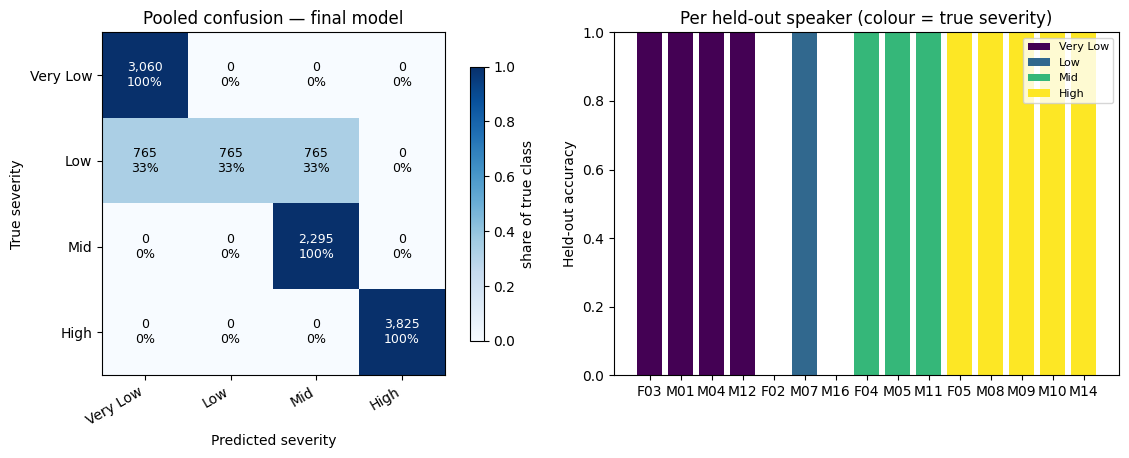

In [9]:
names = config.SEVERITY_CLASS_NAMES
matrix = (pd.crosstab(preds["y_true"], preds["y_pred"])
          .reindex(index=range(4), columns=range(4), fill_value=0).to_numpy())
share = matrix / np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
per_fold = pd.DataFrame(final["folds"])
figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4.6))
image = left.imshow(share, cmap="Blues", vmin=0, vmax=1)
left.set_xticks(range(4), names, rotation=30, ha="right")
left.set_yticks(range(4), names)
left.set_xlabel("Predicted severity")
left.set_ylabel("True severity")
left.set_title("Pooled confusion — final model")
for i in range(4):
    for j in range(4):
        left.text(j, i, f"{matrix[i, j]:,}\n{share[i, j]:.0%}", ha="center", va="center",
                  fontsize=9, color="white" if share[i, j] > 0.5 else "black")
figure.colorbar(image, ax=left, shrink=0.8, label="share of true class")
ordered = per_fold.assign(order=per_fold["true_label"].map(names.index)).sort_values(["order", "fold"])
right.bar(ordered["fold"], ordered["accuracy"], color=plt.cm.viridis(ordered["order"] / 3))
for index, name in enumerate(names):
    right.bar(0, 0, color=plt.cm.viridis(index / 3), label=name)
right.set_ylim(0, 1)
right.set_ylabel("Held-out accuracy")
right.set_title("Per held-out speaker (colour = true severity)")
right.legend(loc="upper right", fontsize=8)
figure.tight_layout()
plt.show()

Utterance-level four-branch fusion (the single-word view): what the inner loop chose in each outer fold — configurations, fusion weights and decision rule, selected on the 14 training speakers only.

In [10]:
pd.DataFrame([{"Held-out": r["fold"], "True": r["true_label"], "Accuracy": r["accuracy"],
               **{f"w_{b}": w for b, w in r["weights"].items()}, "decoder": r["decoder"],
               "learned layers": r["configs"]["learned"]["variant"],
               "learned PCA / C": f"{r['configs']['learned']['pca_dims']} / {r['configs']['learned']['C']}",
               "segmental PCA / C": f"{r['configs']['segmental']['pca_dims']} / {r['configs']['segmental']['C']}",
               "supra C": r["configs"]["supra"]["C"],
               "asr C": r["configs"]["asr"]["C"]} for r in outputs[FINAL_TAG]["folds"]]
             ).style.format({"Accuracy": "{:.3f}", "w_learned": "{:.1f}", "w_segmental": "{:.1f}",
                             "w_supra": "{:.1f}", "w_asr": "{:.1f}"}).hide(axis="index")

Held-out,True,Accuracy,w_asr,w_learned,w_segmental,w_supra,decoder,learned layers,learned PCA / C,segmental PCA / C,supra C,asr C
F03,Very Low,0.685,1.0,0.0,0.0,0.0,argmax,late,16 / 0.3,8 / 0.003,0.003000,0.300000
F02,Low,0.061,0.7,0.3,0.0,0.0,argmax,late,16 / 0.03,16 / 0.003,0.003000,0.300000
F04,Mid,0.018,0.4,0.3,0.3,0.0,argmax,early,8 / 0.3,32 / 0.003,0.003000,0.030000
F05,High,0.958,0.5,0.4,0.0,0.1,argmax,all,16 / 0.03,32 / 0.3,0.003000,0.300000
M01,Very Low,0.337,0.5,0.3,0.0,0.2,argmax,all,16 / 0.3,16 / 0.03,0.300000,0.030000
M07,Low,0.093,0.7,0.3,0.0,0.0,argmax,early,8 / 0.3,8 / 0.003,0.003000,0.030000
M05,Mid,0.209,0.9,0.0,0.0,0.1,argmax,all,8 / 0.003,16 / 0.003,0.003000,0.030000
M08,High,0.847,0.4,0.5,0.0,0.1,argmax,late,16 / 0.003,8 / 0.003,0.003000,0.300000
M04,Very Low,0.490,0.5,0.5,0.0,0.0,argmax,all,8 / 0.003,8 / 0.003,0.003000,0.030000
M16,Low,0.089,0.6,0.3,0.0,0.1,argmax,late,8 / 0.3,32 / 0.3,0.300000,0.030000


## 6. End-to-end model (comparison, off by default)

In [11]:
RUN_END_TO_END = False

end_to_end = pd.DataFrame([
    {"Model": "End-to-end gated fusion v1 (LoRA)", "Accuracy": 0.453, "Macro F1": 0.312,
     "Balanced acc.": 0.378, "Ordinal MAE": 0.998, "Speakers correct": "8/15"},
    {"Model": "End-to-end gated fusion v2 (LoRA)", "Accuracy": 0.370, "Macro F1": 0.296,
     "Balanced acc.": 0.318, "Ordinal MAE": 1.132, "Speakers correct": "6/15"},
])
ours = summary[summary["Model"].isin([PRIMARY_TAG, FINAL_TAG, "fusion_raw", "majority_baseline"])][end_to_end.columns]
(pd.concat([ours, end_to_end], ignore_index=True).style
 .format({c: "{:.3f}" for c in ("Accuracy", "Macro F1", "Balanced acc.", "Ordinal MAE")}, na_rep="N/A")
 .hide(axis="index").set_caption("Final model vs. the end-to-end network (same 15-fold protocol)"))

Model,Accuracy,Macro F1,Balanced acc.,Ordinal MAE,Speakers correct
session_nested,0.867,0.812,0.833,0.133,13/15
fusion_ref,0.461,0.384,0.394,0.711,7/15
fusion_raw,0.493,0.407,0.427,0.678,8/15
majority_baseline,0.333,0.125,0.250,1.400,5/15
End-to-end gated fusion v1 (LoRA),0.453,0.312,0.378,0.998,8/15
End-to-end gated fusion v2 (LoRA),0.370,0.296,0.318,1.132,6/15


### 6.1 Run parameters
`MODEL` selects the full network or one of eight ablations; each gets its own `RUN_NAME`.

In [12]:
if RUN_END_TO_END:
    MODEL = SEVERITY_MODEL_NAME              # or: ab1_wav2vec2_only, ab2_acoustic_only, ab3_wav2vec2_acoustic_concat,
                                             #     ab4_wav2vec2_segmental, ab5_wav2vec2_suprasegmental,
                                             #     ab6_full_fusion, ab7_full_complementarity, ab8_full_speaker_grl
    RUN_BLOCKS = ["B1", "B2", "B3"]          # all 765 utterances per speaker
    EPOCHS, PATIENCE = config.DEFAULT_EPOCHS, config.DEFAULT_PATIENCE
    BATCH_SIZE = config.DEFAULT_BATCH_SIZE
    GRADIENT_CHECKPOINTING = config.WAV2VEC_GRADIENT_CHECKPOINTING
    SESSION_HOURS = None                     # e.g. 8: stop cleanly before 8 h; re-run to continue
    RUN_BENCHMARK = False                    # True: re-measure batch size x checkpointing (~7 min)
    SMOKE_TEST = os.environ.get("AAFA_SMOKE") == "1"

    RUN_TAG = "v2"                          # new protocol (min epochs, smoothed monitor, 2 val speakers/class): do not mix with v1 folds
    RUN_NAME = f"sev_{MODEL}_{'+'.join(RUN_BLOCKS)}_{RUN_TAG}" + ("_smoke" if SMOKE_TEST else "")
    df_run = subset_blocks(df_full, RUN_BLOCKS)
    df_dysarthric = df_run[df_run["Speaker_ID"].isin(config.DYSARTHRIC_IDS)].reset_index(drop=True)

    # Every fold must be present and complete: a missing speaker would silently
    # drop a LOSO fold, a short one would bias its test set.
    per_speaker = df_dysarthric.groupby("Speaker_ID").size()
    expected_per_speaker = len(RUN_BLOCKS) * config.WORDS_PER_SPEAKER // 3
    assert sorted(per_speaker.index) == sorted(config.DYSARTHRIC_IDS), "a dysarthric speaker is missing"
    assert (per_speaker == expected_per_speaker).all(), per_speaker[per_speaker != expected_per_speaker]
    fold_ids = [fold_id for fold_id, _, _ in build_folds(df_run)]

    print_kv("Run name", RUN_NAME)
    print_kv("Severity utterances", f"{len(df_dysarthric):,} = 15 speakers x {expected_per_speaker}")
    print_kv("LOSO folds", f"{len(fold_ids)}: {', '.join(fold_ids)}")
    print_kv("Speakers per class", ", ".join(f"{c} {sum(config.SEVERITY_MAP[s] == c for s in config.DYSARTHRIC_IDS)}"
                                              for c in config.SEVERITY_CLASS_NAMES))
    if SMOKE_TEST:
        print_note("SMOKE TEST — pipeline check only, not a result.")

### 6.2 Model and one real batch

In [13]:
if RUN_END_TO_END:
    from torch.utils.data import DataLoader
    from src.dataset import UASpeechDataset

    batch = next(iter(DataLoader(UASpeechDataset(df_dysarthric.sample(n=4, random_state=config.DEFAULT_SEED)),
                                 batch_size=4)))
    assert batch["segmental"].shape[1:] == (config.SEGMENTAL_CHANNELS, 401)
    assert batch["supra"].shape[1:] == (config.SUPRA_CHANNELS, 401)
    assert batch["waveform"].shape[-1] == config.MAX_SAMPLES
    print_status("A real batch matches the model's input contract "
                 + ", ".join(f"{k} {tuple(batch[k].shape)}" for k in ("waveform", "segmental", "supra")), ok=True)

    model_preview = build_model(MODEL, num_speakers=11, gradient_checkpointing=GRADIENT_CHECKPOINTING)
    counts = parameter_counts(model_preview)
    print_header(f"Model — {MODEL}")
    print_kv("Trainable parameters", f"{counts['trainable_params']:,} of {counts['total_params']:,} "
                                     f"({counts['trainable_pct']:.2f}%): LoRA adapters, branches, heads")
    print_feature_audit(model_preview)
    del model_preview
    torch.cuda.empty_cache()

### 6.3 Throughput and projected run time

In [14]:
if RUN_END_TO_END:
    if RUN_BENCHMARK:
        from src.training.session import benchmark_batch_sizes
        measurement, _ = benchmark_batch_sizes(df_run, model_name=MODEL, batch_sizes=(32, 64))
        BATCH_SIZE, GRADIENT_CHECKPOINTING = measurement.batch_size, measurement.gradient_checkpointing
    else:
        measurement = calibrate_throughput(df_run, model_name=MODEL, batch_size=BATCH_SIZE,
                                           gradient_checkpointing=GRADIENT_CHECKPOINTING)
    projection = project_runtime(df_run, measurement, epochs=EPOCHS)
    print_header("Projected run time")
    print_kv("Mean fold (train / val / test)", f"{projection['n_train']} / {projection['n_val']} / {projection['n_test']}")
    print_kv("Epoch / fold at max epochs", f"{projection['epoch_seconds'] / 60:.1f} min / {projection['fold_seconds'] / 60:.0f} min")
    print_kv(f"{projection['n_folds']} folds, upper bound", f"{projection['total_seconds'] / 3600:.1f} h")

### 6.4 Training
The configuration is frozen under `outputs/results/<RUN_NAME>/`; re-running the same `RUN_NAME` with a different configuration is refused. Interrupting is safe: re-running resumes.

In [15]:
if RUN_END_TO_END:
    cfg = TrainingConfig(
        model=MODEL, run_name=RUN_NAME,
        epochs=1 if SMOKE_TEST else EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        session_hours=SESSION_HOURS, fold_time_estimate_s=projection["fold_seconds"],
        max_folds=2 if SMOKE_TEST else None, limit_samples=64 if SMOKE_TEST else None,
    )
    final_config = print_final_run_configuration(cfg)
    check_frozen_config_guard(final_config)
    print_kv("Frozen to", write_frozen_config(final_config).relative_to(PROJECT_ROOT))

In [16]:
if RUN_END_TO_END:
    training_start = time.monotonic()
    torch.cuda.reset_peak_memory_stats()
    e2e_summary, e2e_pooled = run_training(df_run, cfg)
    print_kv("Training wall clock", f"{(time.monotonic() - training_start) / 3600:.2f} h")
    print_kv("Peak GPU memory", f"{torch.cuda.max_memory_allocated() / 2**30:.2f} GiB")

### 6.5 End-to-end results
Rebuilt from the files on disk.

In [17]:
if RUN_END_TO_END:
    from IPython.display import Markdown

    expected_folds = fold_ids[:cfg.max_folds] if cfg.max_folds else fold_ids
    results = collect_run_results(RUN_NAME, expected_folds)
    cov = results["coverage"]
    display(Markdown(
        f"### Run status: **{cov['status']}** — {cov['completed']} / {cov['expected']} folds ({cov['completion_pct']:.0f}%)\n"
        + (f"- Missing: {', '.join(cov['missing_folds'])}\n" if cov["missing_folds"] else "")
        + (f"- Failed: {', '.join(cov['failed_folds'])}\n" if cov["failed_folds"] else "")
        + ("\n> **Partial — not a final result.** Re-run the training cell to finish the missing folds.\n"
           if cov["status"] != "COMPLETE" else "")))

    per_fold = results["per_fold"]
    if per_fold.empty:
        display(Markdown("_No fold has finished yet._"))
    else:
        display(per_fold.style
                .format({"Accuracy": "{:.3f}", "Ordinal MAE": "{:.3f}", "Train (min)": "{:.1f}"}, na_rep="N/A")
                .background_gradient(subset=["Accuracy"], cmap="RdYlGn", vmin=0, vmax=1)
                .background_gradient(subset=["Ordinal MAE"], cmap="RdYlGn_r", vmin=0, vmax=3)
                .hide(axis="index").set_caption("Per held-out speaker"))

In [18]:
if RUN_END_TO_END:
    if "pooled" in results:
        tag = "" if cov["status"] == "COMPLETE" else f" — {cov['status']}, NOT A FINAL RESULT"
        display(Markdown(f"### Pooled over {cov['completed']} held-out speakers ({results['n_utterances']:,} utterances){tag}"))
        display(results["pooled"].style.format({"Value": "{:.4f}"}, na_rep="N/A").hide(axis="index"))
        display(results["per_class"].style.format(
            {c: "{:.3f}" for c in ("precision", "recall", "f1", "auroc_ovr")}, na_rep="N/A")
            .hide(axis="index").set_caption("Per class (N/A: never predicted, or absent from the pooled set)"))
        display(results["speakers"].style.format({"Utterance accuracy": "{:.3f}"}).hide(axis="index")
                .set_caption("Speaker level — median of each speaker's utterance predictions"))

In [19]:
if RUN_END_TO_END:
    if "confusion" in results:
        names = config.SEVERITY_CLASS_NAMES
        matrix = results["confusion"].to_numpy()
        share = matrix / np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
        figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4.6))
        image = left.imshow(share, cmap="Blues", vmin=0, vmax=1)
        left.set_xticks(range(4), names, rotation=30, ha="right")
        left.set_yticks(range(4), names)
        left.set_xlabel("Predicted severity")
        left.set_ylabel("True severity")
        left.set_title(f"Pooled confusion — {cov['completed']}/{cov['expected']} folds")
        for i in range(4):
            for j in range(4):
                left.text(j, i, f"{matrix[i, j]:,}\n{share[i, j]:.0%}", ha="center", va="center",
                          fontsize=9, color="white" if share[i, j] > 0.5 else "black")
        figure.colorbar(image, ax=left, shrink=0.8, label="share of true class")

        ordered = per_fold.assign(order=per_fold["True class"].map(names.index)).sort_values(["order", "Fold"])
        right.bar(ordered["Fold"], ordered["Accuracy"], color=plt.cm.viridis(ordered["order"] / 3))
        for index, name in enumerate(names):
            right.bar(0, 0, color=plt.cm.viridis(index / 3), label=name)
        right.set_ylim(0, 1)
        right.set_ylabel("Held-out accuracy")
        right.set_title("Per held-out speaker (colour = true severity)")
        right.legend(loc="upper right", fontsize=8)
        figure.tight_layout()
        plt.show()

In [20]:
print_kv("Artifacts", config.OUTPUT_DIR)
print_kv("Whole notebook", f"{(time.monotonic() - SESSION_START) / 60:.1f} min")

  Artifacts ............................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs
  Whole notebook .......................... 83.2 min
